# 05 - CNN Model Training

**Cycle Rack Audio Classification Project**

This notebook trains Convolutional Neural Network models on mel-spectrograms.

## Approaches:
1. **Custom CNN Architecture**: Built from scratch for audio classification
2. **Transfer Learning with YAMNet**: Pre-trained on AudioSet (521 classes)

## Training Pipeline:
- Load preprocessed spectrograms from notebook 03
- Build and compile CNN models
- Train with early stopping and learning rate reduction
- Evaluate on validation and test sets
- Compare custom CNN vs transfer learning

In [2]:
pip install tensorflow-metal tensorflow-macos

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 MB 28.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 44.6 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: protobuf━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/20 [libclang]
    Found existing installation: protobuf 6.33.0━━━━━━━━━━━━━━  1/20 [libclang]
    Uninstalling protobuf-6.33.0:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/20 [libclang]
      Successfully uninstalled protobuf-6.33.0━━━━━━━━━━━━━━━━  1/20 [libclang]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20/20 [tensorflow-macos][tensorflow]]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-st

In [4]:
# Import required libraries
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import json

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Check for GPU
print(f"\nGPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Number of GPUs: {len(tf.config.list_physical_devices('GPU'))}")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!
TensorFlow version: 2.16.2
Keras version: 3.11.3

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Number of GPUs: 1


## Configuration and Path Setup

In [5]:
# Get paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"
SPECTROGRAMS_DIR = DATA_DIR / "spectrograms"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

# Create directories
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Path Configuration:")
print(f"  Spectrograms directory: {SPECTROGRAMS_DIR}")
print(f"  Models directory: {MODELS_DIR}")
print(f"  Results directory: {RESULTS_DIR}")
print(f"\nPath checks:")
print(f"  Spectrograms directory exists: {SPECTROGRAMS_DIR.exists()}")

# Training configuration
CONFIG = {
    'BATCH_SIZE': 32,
    'EPOCHS': 100,
    'LEARNING_RATE': 0.001,
    'PATIENCE': 15,  # Early stopping patience
    'REDUCE_LR_PATIENCE': 5,  # ReduceLROnPlateau patience
    'RANDOM_STATE': 42
}

print(f"\nTraining Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

# Set random seeds for reproducibility
np.random.seed(CONFIG['RANDOM_STATE'])
tf.random.set_seed(CONFIG['RANDOM_STATE'])

Path Configuration:
  Spectrograms directory: /Users/harryirving/Development/projects/ai-ml/BikeAIv2/data/spectrograms
  Models directory: /Users/harryirving/Development/projects/ai-ml/BikeAIv2/models
  Results directory: /Users/harryirving/Development/projects/ai-ml/BikeAIv2/results

Path checks:
  Spectrograms directory exists: True

Training Configuration:
  BATCH_SIZE: 32
  EPOCHS: 100
  LEARNING_RATE: 0.001
  PATIENCE: 15
  REDUCE_LR_PATIENCE: 5
  RANDOM_STATE: 42


## Load Preprocessed Spectrograms

In [6]:
# Load train/val/test splits
print("Loading preprocessed spectrograms...")
X_train = np.load(SPECTROGRAMS_DIR / 'X_train.npy')
y_train = np.load(SPECTROGRAMS_DIR / 'y_train.npy')
X_val = np.load(SPECTROGRAMS_DIR / 'X_val.npy')
y_val = np.load(SPECTROGRAMS_DIR / 'y_val.npy')
X_test = np.load(SPECTROGRAMS_DIR / 'X_test.npy')
y_test = np.load(SPECTROGRAMS_DIR / 'y_test.npy')

print(f"\nData loaded:")
print(f"  Training: {X_train.shape}, labels: {y_train.shape}")
print(f"  Validation: {X_val.shape}, labels: {y_val.shape}")
print(f"  Test: {X_test.shape}, labels: {y_test.shape}")

# Load class mappings
with open(SPECTROGRAMS_DIR / 'class_mappings.json', 'r') as f:
    class_info = json.load(f)

classes = class_info['classes']
num_classes = len(classes)

print(f"\nClasses: {classes}")
print(f"Number of classes: {num_classes}")

# IMPORTANT: Save copy of raw labels before converting
y_train_raw = y_train.copy()
y_val_raw = y_val.copy()
y_test_raw = y_test.copy()  # ← Keep this for evaluation!

# Convert labels to categorical (one-hot encoding)
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"\nOne-hot encoded labels:")
print(f"  Training: {y_train_cat.shape}")
print(f"  Validation: {y_val_cat.shape}")
print(f"  Test: {y_test_cat.shape}")

print(f"\nRaw labels preserved for evaluation:")
print(f"  y_test_raw sample: {y_test_raw[:10]}")



Loading preprocessed spectrograms...

Data loaded:
  Training: (4158, 128, 128, 1), labels: (4158,)
  Validation: (462, 128, 128, 1), labels: (462,)
  Test: (1156, 128, 128, 1), labels: (1156,)

Classes: ['background', 'angle_grinder', 'other_power_tools']
Number of classes: 3

One-hot encoded labels:
  Training: (4158, 3)
  Validation: (462, 3)
  Test: (1156, 3)

Raw labels preserved for evaluation:
  y_test_raw sample: [0 0 0 0 0 0 0 0 0 2]


## Custom CNN Architecture

In [7]:
def build_custom_cnn(input_shape, num_classes):
    """
    Build a custom CNN architecture for audio classification.
    
    Architecture inspired by VGG-style networks but optimized for spectrograms.
    Uses Conv2D layers with increasing filters, batch normalization,
    max pooling, and dropout for regularization.
    """
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),
        
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Fully connected layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build model
input_shape = X_train.shape[1:]  # (128, 128, 1)
custom_cnn = build_custom_cnn(input_shape, num_classes)

print("Custom CNN Architecture:")
custom_cnn.summary()

# Compile model
custom_cnn.compile(
    optimizer=Adam(learning_rate=CONFIG['LEARNING_RATE']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✓ Custom CNN compiled")

2025-10-22 14:01:45.063699: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-10-22 14:01:45.063736: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-10-22 14:01:45.063739: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-10-22 14:01:45.063766: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-22 14:01:45.063775: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Custom CNN Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,108,707 (34.75 MB)

 Trainable params: 9,105,763 (34.74 MB)

 Non-trainable params: 2,944 (11.50 KB)


✓ Custom CNN compiled


In [8]:
# Define callbacks
custom_cnn_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=CONFIG['PATIENCE'],
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=CONFIG['REDUCE_LR_PATIENCE'],
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / 'custom_cnn_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Training Custom CNN...")
print(f"{'='*60}")

# Train model
history_custom = custom_cnn.fit(
    X_train, y_train_cat,
    batch_size=CONFIG['BATCH_SIZE'],
    epochs=CONFIG['EPOCHS'],
    validation_data=(X_val, y_val_cat),
    callbacks=custom_cnn_callbacks,
    verbose=1
)

print("\n✓ Custom CNN training complete")

Training Custom CNN...
Epoch 1/100


2025-10-22 14:01:47.265564: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.6105 - loss: 1.2155
Epoch 1: val_accuracy improved from None to 0.93290, saving model to /Users/harryirving/Development/projects/ai-ml/BikeAIv2/models/custom_cnn_best.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 36s 212ms/step - accuracy: 0.7576 - loss: 0.8220 - val_accuracy: 0.9329 - val_loss: 0.4102 - learning_rate: 0.0010
Epoch 2/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9393 - loss: 0.3034
Epoch 2: val_accuracy did not improve from 0.93290
130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 195ms/step - accuracy: 0.9440 - loss: 0.2661 - val_accuracy: 0.9329 - val_loss: 0.4795 - learning_rate: 0.0010
Epoch 3/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9605 - loss: 0.1641
Epoch 3: val_accuracy improved from 0.93290 to 0.96320, saving model to /Users/harryirving/Development/projects/ai-ml/BikeAIv2/models/custom_cnn_best.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 194ms/step - accuracy: 0.9594 - loss: 0.1723 - val_accuracy: 0.9632 - val_loss: 0.1614 - learning_rate: 0.0010
Epoch 4/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9655 - loss: 0.1227
Epoch 4: val_accuracy did not improve from 0.96320
130/130 ━━━━━━━━━━━━━━━━━━━━ 26s 197ms/step - accuracy: 0.9707 - loss: 0.1097 - val_accuracy: 0.9545 - val_loss: 0.1244 - learning_rate: 0.0010
Epoch 5/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9780 - loss: 0.0802
Epoch 5: val_accuracy improved from 0.96320 to 0.98268, saving model to /Users/harryirving/Development/projects/ai-ml/BikeAIv2/models/custom_cnn_best.h5


...

130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 194ms/step - accuracy: 0.9817 - loss: 0.0569 - val_accuracy: 0.9848 - val_loss: 0.0607 - learning_rate: 0.0010
Epoch 8/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9870 - loss: 0.0422
Epoch 8: val_accuracy did not improve from 0.98485
130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 193ms/step - accuracy: 0.9885 - loss: 0.0452 - val_accuracy: 0.9848 - val_loss: 0.0337 - learning_rate: 0.0010
Epoch 9/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9875 - loss: 0.0397
Epoch 9: val_accuracy did not improve from 0.98485
130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 193ms/step - accuracy: 0.9853 - loss: 0.0481 - val_accuracy: 0.9545 - val_loss: 0.2203 - learning_rate: 0.0010
Epoch 10/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 722ms/step - accuracy: 0.9859 - loss: 0.0445
Epoch 10: val_accuracy did not improve from 0.98485
130/130 ━━━━━━━━━━━━━━━━━━━━ 94s 726ms/step - accuracy: 0.9836 - loss: 0.0571 - val_accuracy: 0.3463 - val_loss: 5.5885 - learning_rate: 0.0010
Ep

130/130 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.9856 - loss: 0.0502 - val_accuracy: 0.9913 - val_loss: 0.0323 - learning_rate: 0.0010
Epoch 12/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.9883 - loss: 0.0372
Epoch 12: val_accuracy did not improve from 0.99134
130/130 ━━━━━━━━━━━━━━━━━━━━ 51s 389ms/step - accuracy: 0.9851 - loss: 0.0500 - val_accuracy: 0.9567 - val_loss: 0.1719 - learning_rate: 0.0010
Epoch 13/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - accuracy: 0.9865 - loss: 0.0469
Epoch 13: val_accuracy did not improve from 0.99134
130/130 ━━━━━━━━━━━━━━━━━━━━ 114s 884ms/step - accuracy: 0.9877 - loss: 0.0458 - val_accuracy: 0.9740 - val_loss: 0.0744 - learning_rate: 0.0010
Epoch 14/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9924 - loss: 0.0263
Epoch 14: val_accuracy improved from 0.99134 to 0.99351, saving model to /Users/harryirving/Development/projects/ai-ml/BikeAIv2/models/custom_cnn_best.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 27s 211ms/step - accuracy: 0.9901 - loss: 0.0349 - val_accuracy: 0.9935 - val_loss: 0.0265 - learning_rate: 0.0010
Epoch 15/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9924 - loss: 0.0239
Epoch 15: val_accuracy did not improve from 0.99351
130/130 ━━━━━━━━━━━━━━━━━━━━ 26s 199ms/step - accuracy: 0.9909 - loss: 0.0312 - val_accuracy: 0.9784 - val_loss: 0.0665 - learning_rate: 0.0010
Epoch 16/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.9850 - loss: 0.0444
Epoch 16: val_accuracy did not improve from 0.99351
130/130 ━━━━━━━━━━━━━━━━━━━━ 26s 198ms/step - accuracy: 0.9870 - loss: 0.0426 - val_accuracy: 0.8333 - val_loss: 0.4286 - learning_rate: 0.0010
Epoch 17/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9908 - loss: 0.0272
Epoch 17: val_accuracy did not improve from 0.99351
130/130 ━━━━━━━━━━━━━━━━━━━━ 26s 198ms/step - accuracy: 0.9906 - loss: 0.0286 - val_accuracy: 0.9913 - val_loss: 0.0276 - learning_rate: 0.001

130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 193ms/step - accuracy: 0.9954 - loss: 0.0174 - val_accuracy: 0.9957 - val_loss: 0.0203 - learning_rate: 5.0000e-04
Epoch 21/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9945 - loss: 0.0170
Epoch 21: val_accuracy did not improve from 0.99567
130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 194ms/step - accuracy: 0.9942 - loss: 0.0186 - val_accuracy: 0.9957 - val_loss: 0.0188 - learning_rate: 5.0000e-04
Epoch 22/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9972 - loss: 0.0079
Epoch 22: val_accuracy did not improve from 0.99567
130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 193ms/step - accuracy: 0.9974 - loss: 0.0082 - val_accuracy: 0.9913 - val_loss: 0.0268 - learning_rate: 5.0000e-04
Epoch 23/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9971 - loss: 0.0103
Epoch 23: val_accuracy did not improve from 0.99567
130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 192ms/step - accuracy: 0.9964 - loss: 0.0131 - val_accuracy: 0.9913 - val_loss: 0.0284 - learning

130/130 ━━━━━━━━━━━━━━━━━━━━ 28s 214ms/step - accuracy: 0.9981 - loss: 0.0052 - val_accuracy: 0.9978 - val_loss: 0.0137 - learning_rate: 5.0000e-04
Epoch 29/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.9974 - loss: 0.0096
Epoch 29: val_accuracy did not improve from 0.99784
130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 194ms/step - accuracy: 0.9976 - loss: 0.0094 - val_accuracy: 0.9870 - val_loss: 0.0239 - learning_rate: 5.0000e-04
Epoch 30/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9947 - loss: 0.0114
Epoch 30: val_accuracy did not improve from 0.99784
130/130 ━━━━━━━━━━━━━━━━━━━━ 26s 196ms/step - accuracy: 0.9959 - loss: 0.0106 - val_accuracy: 0.9957 - val_loss: 0.0105 - learning_rate: 5.0000e-04
Epoch 31/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9958 - loss: 0.0117
Epoch 31: val_accuracy did not improve from 0.99784
130/130 ━━━━━━━━━━━━━━━━━━━━ 27s 206ms/step - accuracy: 0.9962 - loss: 0.0140 - val_accuracy: 0.9892 - val_loss: 0.0397 - learning

## Transfer Learning with YAMNet

YAMNet is pre-trained on AudioSet (521 audio event classes) and uses MobileNetV1 architecture, making it efficient for deployment on resource-constrained devices like ESP32.

In [9]:
def build_transfer_learning_model(input_shape, num_classes):
    """
    Build a transfer learning model using MobileNetV2 as base.
    
    Note: MobileNetV2 requires 3-channel input. We convert grayscale 
    spectrograms to 3-channel by repeating the channel.
    """
    # Convert 1-channel to 3-channel input
    inputs = layers.Input(shape=input_shape)
    
    # Repeat grayscale channel 3 times to create RGB-like input
    if input_shape[-1] == 1:
        x = layers.Concatenate()([inputs, inputs, inputs])
    else:
        x = inputs
    
    # Load pre-trained MobileNetV2 (excluding top layers)
    base_model = keras.applications.MobileNetV2(
        input_shape=(input_shape[0], input_shape[1], 3),  # 3 channels
        include_top=False,
        weights='imagenet'
    )
    
    # Freeze base model layers initially
    base_model.trainable = False
    
    # Build complete model
    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    return model, base_model

# Build transfer learning model
transfer_model, base_model = build_transfer_learning_model(input_shape, num_classes)

print("Transfer Learning Model (MobileNetV2-based):")
transfer_model.summary()

# Compile model
transfer_model.compile(
    optimizer=Adam(learning_rate=CONFIG['LEARNING_RATE']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n✓ Transfer learning model compiled")
print(f"Base model trainable: {base_model.trainable}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Transfer Learning Model (MobileNetV2-based):


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_1[0]… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ concatenate[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1280)      │      5,120 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 1280)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    327,936 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 3)         │        771 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,592,835 (9.89 MB)

 Trainable params: 331,779 (1.27 MB)

 Non-trainable params: 2,261,056 (8.63 MB)


✓ Transfer learning model compiled
Base model trainable: False


In [10]:
# Phase 1: Train with frozen base model
transfer_callbacks_phase1 = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Phase 1: Training transfer learning model (frozen base)...")
print(f"{'='*60}")

history_transfer_phase1 = transfer_model.fit(
    X_train, y_train_cat,
    batch_size=CONFIG['BATCH_SIZE'],
    epochs=20,  # Fewer epochs for phase 1
    validation_data=(X_val, y_val_cat),
    callbacks=transfer_callbacks_phase1,
    verbose=1
)

print("\n✓ Phase 1 training complete")

Phase 1: Training transfer learning model (frozen base)...
Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.7299 - loss: 0.7588 - val_accuracy: 0.9870 - val_loss: 0.1274 - learning_rate: 0.0010
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9300 - loss: 0.2203 - val_accuracy: 0.9935 - val_loss: 0.0366 - learning_rate: 0.0010
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9723 - loss: 0.0938 - val_accuracy: 0.9957 - val_loss: 0.0214 - learning_rate: 0.0010
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9786 - loss: 0.0624 - val_accuracy: 0.9957 - val_loss: 0.0149 - learning_rate: 0.0010
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9861 - loss: 0.0457 - val_accuracy: 0.9957 - val_loss: 0.0118 - learning_rate: 0.0010
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.9863 - loss: 0.0422 - val_accuracy: 0.9957 - val_loss: 0.0103 - learning_rate: 0.0010
Epoch 7/20
130/130 ━━━

In [11]:
# Phase 2: Fine-tune by unfreezing top layers
print("Phase 2: Fine-tuning (unfreezing top layers)...")

# Unfreeze the top 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Base model layers: {len(base_model.layers)}")
print(f"Trainable layers: {sum(1 for layer in base_model.layers if layer.trainable)}")

# Recompile with lower learning rate for fine-tuning
transfer_model.compile(
    optimizer=Adam(learning_rate=CONFIG['LEARNING_RATE'] / 10),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_callbacks_phase2 = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=CONFIG['PATIENCE'],
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=CONFIG['REDUCE_LR_PATIENCE'],
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=str(MODELS_DIR / 'transfer_model_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print(f"\n{'='*60}")
history_transfer_phase2 = transfer_model.fit(
    X_train, y_train_cat,
    batch_size=CONFIG['BATCH_SIZE'],
    epochs=CONFIG['EPOCHS'],
    validation_data=(X_val, y_val_cat),
    callbacks=transfer_callbacks_phase2,
    verbose=1
)

print("\n✓ Fine-tuning complete")

Phase 2: Fine-tuning (unfreezing top layers)...
Base model layers: 154
Trainable layers: 30

Epoch 1/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9694 - loss: 0.1052
Epoch 1: val_accuracy improved from None to 0.98918, saving model to /Users/harryirving/Development/projects/ai-ml/BikeAIv2/models/transfer_model_best.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - accuracy: 0.9752 - loss: 0.0834 - val_accuracy: 0.9892 - val_loss: 0.0396 - learning_rate: 1.0000e-04
Epoch 2/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9894 - loss: 0.0351
Epoch 2: val_accuracy did not improve from 0.98918
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9911 - loss: 0.0309 - val_accuracy: 0.9892 - val_loss: 0.0547 - learning_rate: 1.0000e-04
Epoch 3/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9958 - loss: 0.0172
Epoch 3: val_accuracy did not improve from 0.98918
130/130 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.9949 - loss: 0.0172 - val_accuracy: 0.9848 - val_loss: 0.0674 - learning_rate: 1.0000e-04
Epoch 4/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9936 - loss: 0.0148
Epoch 4: val_accuracy did not improve from 0.98918
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9945 - loss: 0.0169 - val_accuracy: 0.9848 - val_loss: 0.0593 - learning_rate: 1.0000e

130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9969 - loss: 0.0071 - val_accuracy: 0.9913 - val_loss: 0.0305 - learning_rate: 5.0000e-05
Epoch 8/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9991 - loss: 0.0029
Epoch 8: val_accuracy did not improve from 0.99134
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.9993 - loss: 0.0029 - val_accuracy: 0.9913 - val_loss: 0.0260 - learning_rate: 5.0000e-05
Epoch 9/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9988 - loss: 0.0043
Epoch 9: val_accuracy improved from 0.99134 to 0.99351, saving model to /Users/harryirving/Development/projects/ai-ml/BikeAIv2/models/transfer_model_best.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.9993 - loss: 0.0033 - val_accuracy: 0.9935 - val_loss: 0.0175 - learning_rate: 5.0000e-05
Epoch 10/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9990 - loss: 0.0032
Epoch 10: val_accuracy did not improve from 0.99351
130/130 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.9993 - loss: 0.0028 - val_accuracy: 0.9935 - val_loss: 0.0164 - learning_rate: 5.0000e-05
Epoch 11/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9997 - loss: 0.0023
Epoch 11: val_accuracy improved from 0.99351 to 0.99567, saving model to /Users/harryirving/Development/projects/ai-ml/BikeAIv2/models/transfer_model_best.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - accuracy: 0.9998 - loss: 0.0017 - val_accuracy: 0.9957 - val_loss: 0.0098 - learning_rate: 5.0000e-05
Epoch 12/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9986 - loss: 0.0055
Epoch 12: val_accuracy improved from 0.99567 to 0.99784, saving model to /Users/harryirving/Development/projects/ai-ml/BikeAIv2/models/transfer_model_best.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.9993 - loss: 0.0033 - val_accuracy: 0.9978 - val_loss: 0.0053 - learning_rate: 5.0000e-05
Epoch 13/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9992 - loss: 0.0040
Epoch 13: val_accuracy did not improve from 0.99784
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.9998 - loss: 0.0022 - val_accuracy: 0.9957 - val_loss: 0.0079 - learning_rate: 5.0000e-05
Epoch 14/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9987 - loss: 0.0022
Epoch 14: val_accuracy did not improve from 0.99784
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.9988 - loss: 0.0024 - val_accuracy: 0.9957 - val_loss: 0.0060 - learning_rate: 5.0000e-05
Epoch 15/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 0.0017
Epoch 15: val_accuracy did not improve from 0.99784
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9978 - val_loss: 0.0052 - learning_rate: 

130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 0.0032 - learning_rate: 5.0000e-05
Epoch 17/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9994 - loss: 0.0019
Epoch 17: val_accuracy did not improve from 1.00000
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9990 - loss: 0.0021 - val_accuracy: 0.9978 - val_loss: 0.0034 - learning_rate: 5.0000e-05
Epoch 18/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9999 - loss: 0.0012
Epoch 18: val_accuracy did not improve from 1.00000
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.9998 - loss: 0.0018 - val_accuracy: 0.9978 - val_loss: 0.0034 - learning_rate: 5.0000e-05
Epoch 19/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.0012
Epoch 19: val_accuracy did not improve from 1.00000
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0019 - learning_rate: 

## Training History Visualization

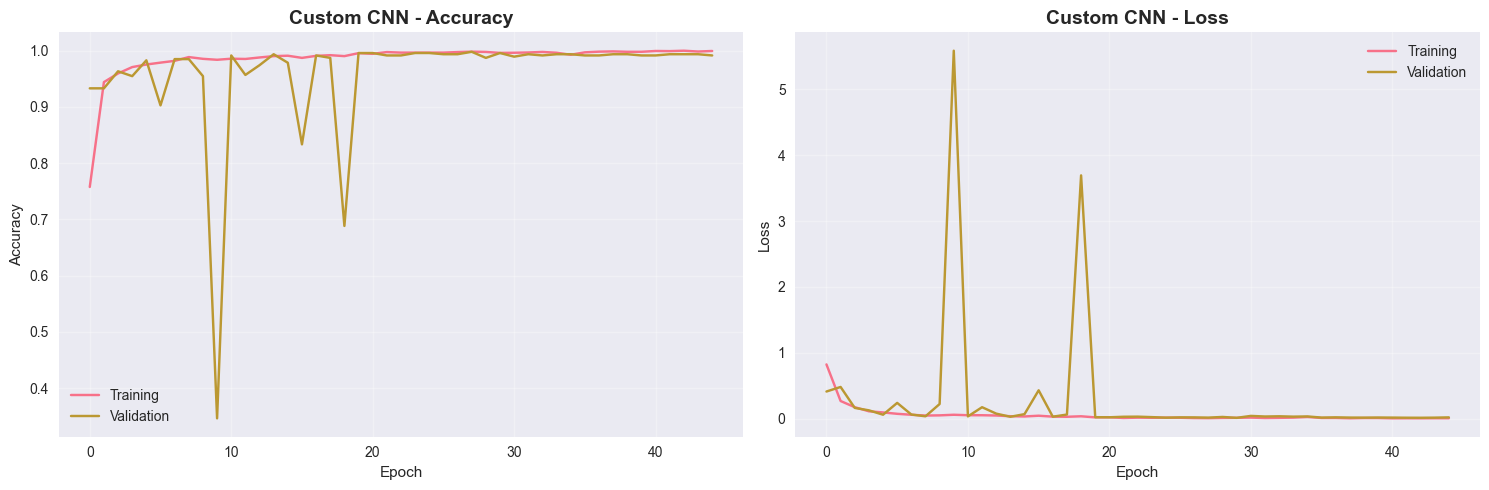

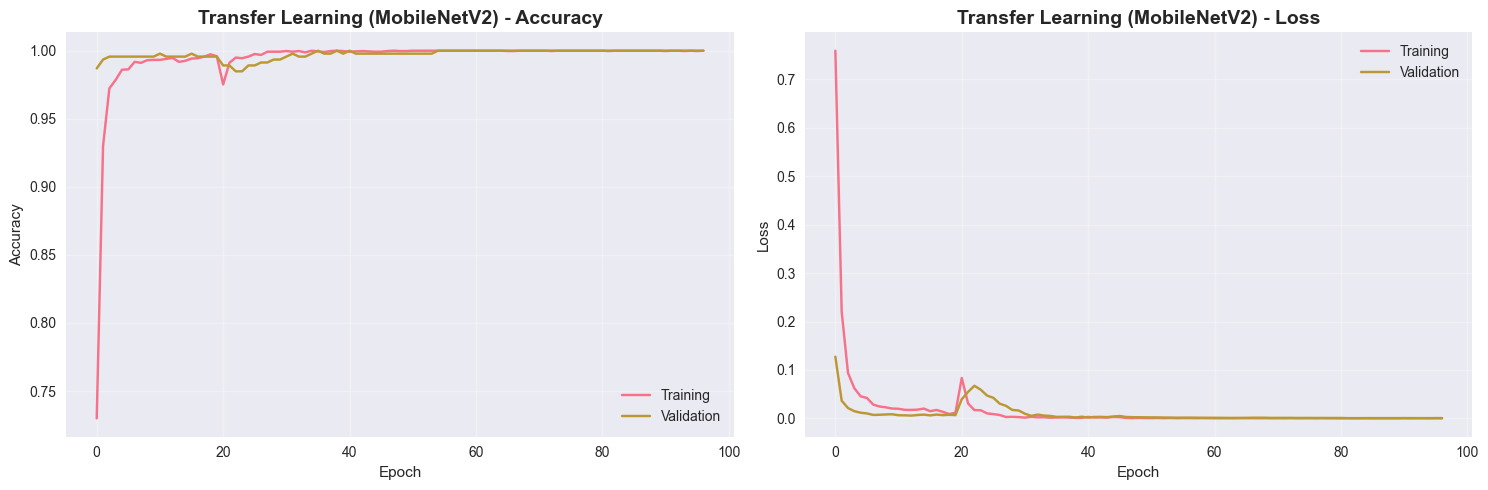

✓ Training history plots saved


In [12]:
def plot_training_history(history, model_name):
    """Plot training and validation accuracy/loss."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Training')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Training')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Plot Custom CNN history
fig_custom = plot_training_history(history_custom, 'Custom CNN')
fig_custom.savefig(RESULTS_DIR / 'training_history_custom_cnn.png', dpi=300, bbox_inches='tight')
plt.show()

# Combine transfer learning phases
combined_history = {
    'accuracy': history_transfer_phase1.history['accuracy'] + history_transfer_phase2.history['accuracy'],
    'val_accuracy': history_transfer_phase1.history['val_accuracy'] + history_transfer_phase2.history['val_accuracy'],
    'loss': history_transfer_phase1.history['loss'] + history_transfer_phase2.history['loss'],
    'val_loss': history_transfer_phase1.history['val_loss'] + history_transfer_phase2.history['val_loss']
}

class CombinedHistory:
    def __init__(self, history_dict):
        self.history = history_dict

combined_history_obj = CombinedHistory(combined_history)

# Plot Transfer Learning history
fig_transfer = plot_training_history(combined_history_obj, 'Transfer Learning (MobileNetV2)')
fig_transfer.savefig(RESULTS_DIR / 'training_history_transfer.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training history plots saved")

## Model Evaluation

In [13]:
def evaluate_model(model, X_test, y_test_cat, y_test_raw, model_name, class_names):
    """Evaluate model and print metrics."""
    print(f"\n{'='*60}")
    print(f"Evaluating {model_name}")
    print(f"{'='*60}")
    
    # Predictions
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Metrics
    test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
    
    print(f"\nTest Metrics:")
    print(f"  Loss: {test_loss:.4f}")
    print(f"  Accuracy: {test_accuracy:.4f}")
    
    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(y_test_raw, y_pred, target_names=class_names, zero_division=0))
    
    # Confusion matrix
    cm = confusion_matrix(y_test_raw, y_pred)
    
    results = {
        'model_name': model_name,
        'test_loss': float(test_loss),
        'test_accuracy': float(test_accuracy),
        'predictions': y_pred,
        'confusion_matrix': cm
    }
    
    return results

# Evaluate Custom CNN
custom_results = evaluate_model(
    custom_cnn, X_test, y_test_cat, y_test_raw,  # ← Use y_test_raw
    'Custom CNN', classes
)

# Evaluate Transfer Learning Model
transfer_results = evaluate_model(
    transfer_model, X_test, y_test_cat, y_test_raw,  # ← Use y_test_raw
    'Transfer Learning (MobileNetV2)', classes
)



Evaluating Custom CNN

Test Metrics:
  Loss: 0.0138
  Accuracy: 0.9965

Classification Report:
                   precision    recall  f1-score   support

       background       1.00      1.00      1.00      1078
    angle_grinder       0.95      1.00      0.98        60
other_power_tools       1.00      0.78      0.88        18

         accuracy                           1.00      1156
        macro avg       0.98      0.93      0.95      1156
     weighted avg       1.00      1.00      1.00      1156


Evaluating Transfer Learning (MobileNetV2)

Test Metrics:
  Loss: 0.0119
  Accuracy: 0.9983

Classification Report:
                   precision    recall  f1-score   support

       background       1.00      1.00      1.00      1078
    angle_grinder       0.97      1.00      0.98        60
other_power_tools       1.00      0.89      0.94        18

         accuracy                           1.00      1156
        macro avg       0.99      0.96      0.97      1156
     weighted a

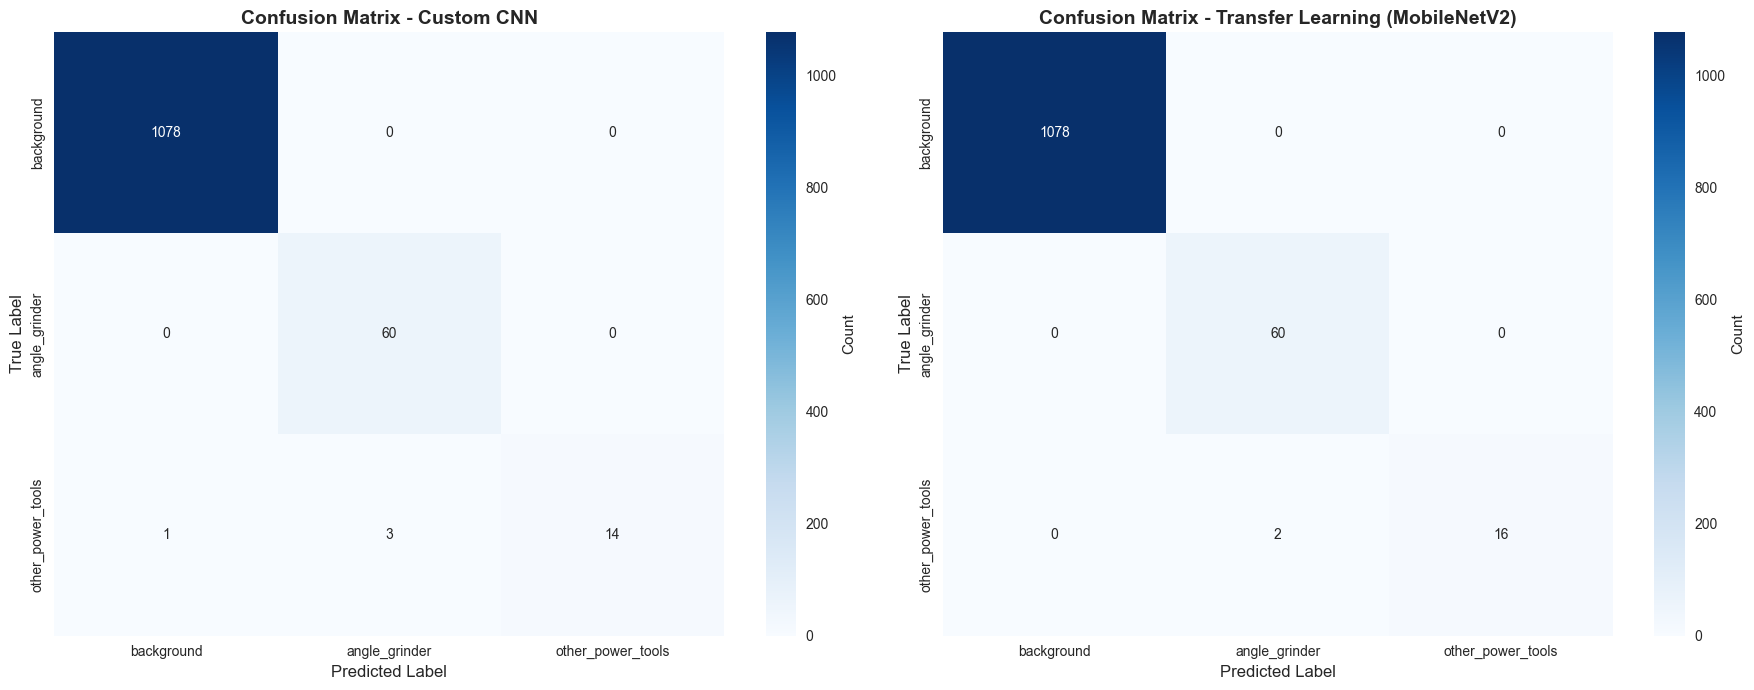

✓ Confusion matrices saved


In [14]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, results in enumerate([custom_results, transfer_results]):
    cm = results['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                ax=axes[idx], cbar_kws={'label': 'Count'})
    axes[idx].set_title(f"Confusion Matrix - {results['model_name']}",
                        fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=12)
    axes[idx].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_cnn.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Confusion matrices saved")


CNN MODEL COMPARISON
                          Model  Test Loss  Test Accuracy
                     Custom CNN   0.013847        0.99654
Transfer Learning (MobileNetV2)   0.011874        0.99827


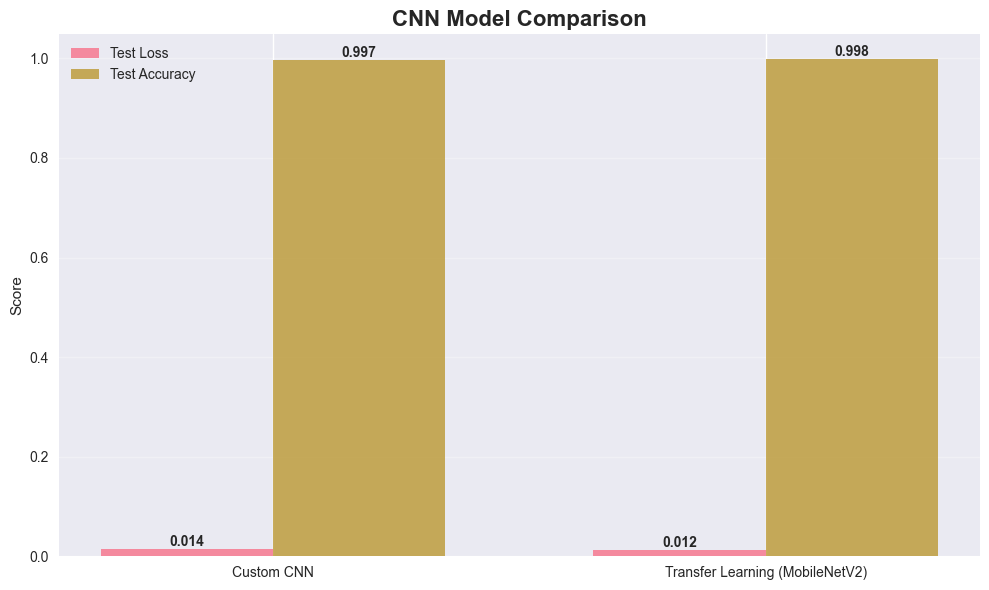


✓ Comparison saved


In [15]:
# Compare models
comparison = pd.DataFrame({
    'Model': ['Custom CNN', 'Transfer Learning (MobileNetV2)'],
    'Test Loss': [custom_results['test_loss'], transfer_results['test_loss']],
    'Test Accuracy': [custom_results['test_accuracy'], transfer_results['test_accuracy']]
})

print(f"\n{'='*60}")
print("CNN MODEL COMPARISON")
print(f"{'='*60}")
print(comparison.to_string(index=False))

# Save comparison
comparison.to_csv(RESULTS_DIR / 'cnn_model_comparison.csv', index=False)

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['Test Loss'], width, label='Test Loss', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison['Test Accuracy'], width, label='Test Accuracy', alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('CNN Model Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cnn_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Comparison saved")

In [16]:
# Save final results
cnn_results = {
    'custom_cnn': {
        'test_loss': custom_results['test_loss'],
        'test_accuracy': custom_results['test_accuracy']
    },
    'transfer_learning': {
        'test_loss': transfer_results['test_loss'],
        'test_accuracy': transfer_results['test_accuracy']
    }
}

with open(RESULTS_DIR / 'cnn_test_results.json', 'w') as f:
    json.dump(cnn_results, f, indent=2)

print(f"✓ CNN test results saved to {RESULTS_DIR / 'cnn_test_results.json'}")

# Save models
custom_cnn.save(MODELS_DIR / 'custom_cnn_final.h5')
transfer_model.save(MODELS_DIR / 'transfer_model_final.h5')
print(f"✓ Models saved to {MODELS_DIR}")

print(f"\n{'='*60}")
print("CNN TRAINING COMPLETE")
print(f"{'='*60}")
print(f"\nAll models trained and evaluated:")
print(f"  - Custom CNN: {custom_results['test_accuracy']:.4f}")
print(f"  - Transfer Learning: {transfer_results['test_accuracy']:.4f}")
print(f"\nResults saved to: {RESULTS_DIR}")
print(f"Models saved to: {MODELS_DIR}")
print(f"\n✓ Ready for final comparison (notebook 06)!")

✓ CNN test results saved to /Users/harryirving/Development/projects/ai-ml/BikeAIv2/results/cnn_test_results.json


✓ Models saved to /Users/harryirving/Development/projects/ai-ml/BikeAIv2/models

CNN TRAINING COMPLETE

All models trained and evaluated:
  - Custom CNN: 0.9965
  - Transfer Learning: 0.9983

Results saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv2/results
Models saved to: /Users/harryirving/Development/projects/ai-ml/BikeAIv2/models

✓ Ready for final comparison (notebook 06)!
